# HomeWork1 Дуркин Макар

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim, mean_squared_error as mse

## 1. Загрузка изображения в оттенках серого

In [12]:
image = cv2.imread('Dog_Gray.jpg', cv2.IMREAD_GRAYSCALE)

In [15]:
print("Высота, ширина")
image.shape

Высота, ширина


(1732, 1690)

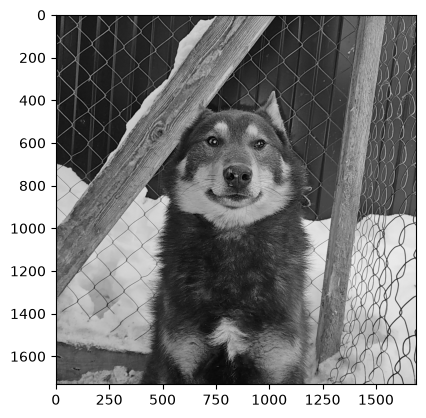

In [16]:
plt.imshow(image, cmap='gray')

## 2. Построение гистограммы

In [17]:
hist = cv2.calcHist([image], [0], None, [256], [0, 256])
hist.shape

(256, 1)

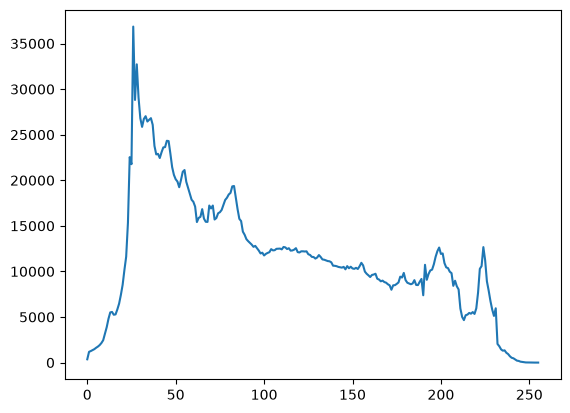

In [18]:
plt.plot(hist)

## 3. Гамма-коррекция

### Алгоритм

$$
\left( \frac{R_{\text{uncorrected}}}{R_{\text{max}}} \right)^{y} \cdot R_{\text{max}}
$$

In [21]:
def gamma_correction(image, gamma):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    return (corrected * 255).astype(np.uint8)
# image - изображение, gamma - параметр 

### Применение

In [23]:
image_bright = gamma_correction(image, 0.5)
image_dark   = gamma_correction(image, 2.0)
print("Средние яркости светлого и темного изображения соответственно")
image_bright.mean(), image_dark.mean()

Средние яркости светлого и темного изображения соответственно


(np.float64(152.6794074640939), np.float64(55.261561009606844))

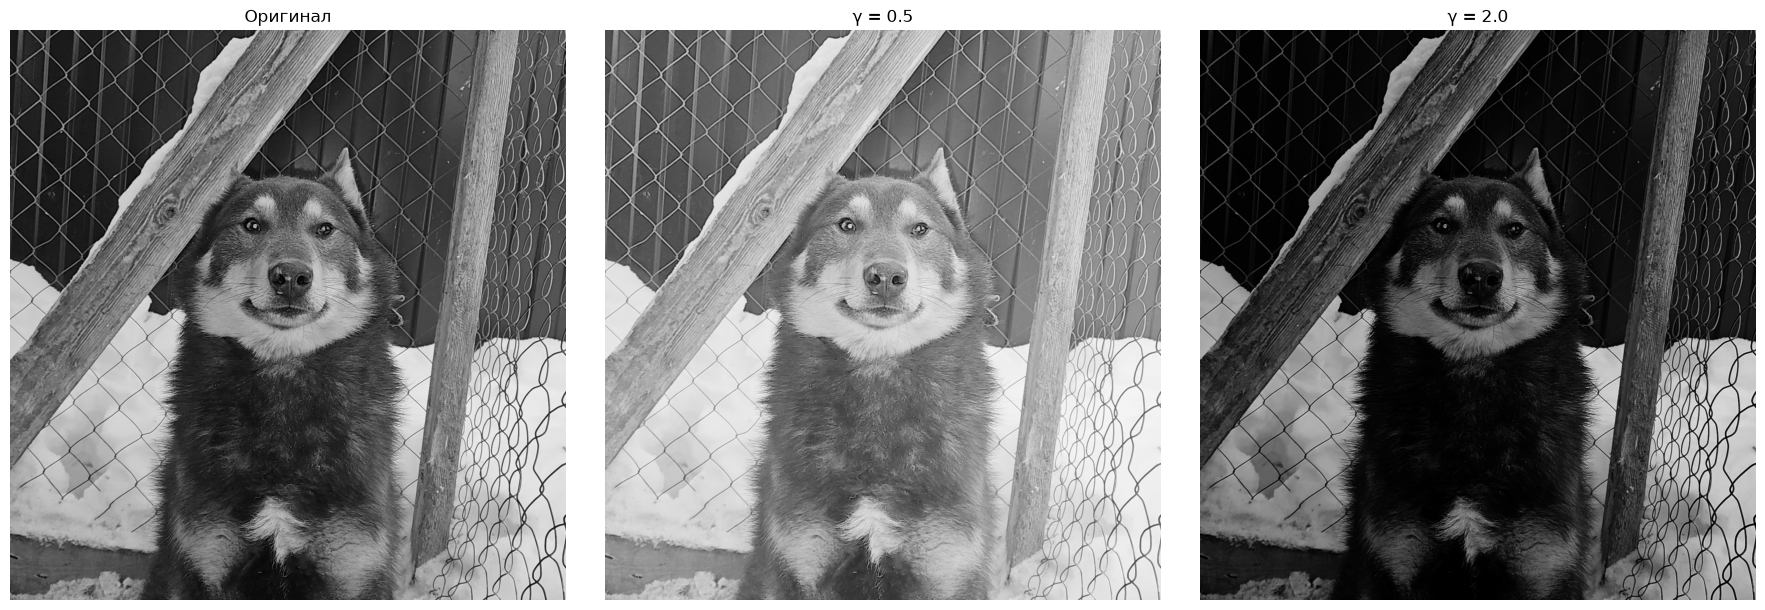

In [27]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray'); plt.title('Оригинал'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_bright, cmap='gray'); plt.title('γ = 0.5'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_dark, cmap='gray'); plt.title('γ = 2.0'); plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Сравнение с помощью MSE и SSIM

In [30]:
mse(image, image_bright), ssim(image, image_bright), mse(image, image_dark), ssim(image, image_dark)
# Сравнение оригинала и светлой по MSE
# Сравнение оригинала и светлой по SSIM
# Сравнение оригинала и темной по MSE
# Сравнение оригинала и темной по SSIM

(np.float64(2768.160626972956),
 np.float64(0.8244321757776891),
 np.float64(2395.8716878254095),
 np.float64(0.6006264564442445))

## 5. Статистическая цветокоррекция на основе статистики eq_gray

### Эквализация гистограммы

$$H'(i) = \sum_{0 \le j < i} H(j)$$

$$H'_{\text{norm}}(i) = \frac{H'(i) - H'_{\min}}{N - H'_{\min}} \cdot 255$$

$$
\text{equalized}(x, y) = H'\bigl(\text{src}(x, y)\bigr)
$$

In [33]:
H = cv2.calcHist([image], [0], None, [256], [0, 256]).flatten()

H_cum = H.cumsum()

H_norm = H_cum / H_cum.max() * 255
H_norm = H_norm.astype(np.uint8)

eq_gray = H_norm[image]

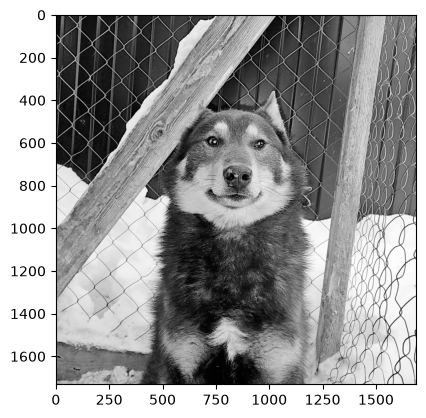

In [34]:
plt.imshow(eq_gray, cmap='gray')

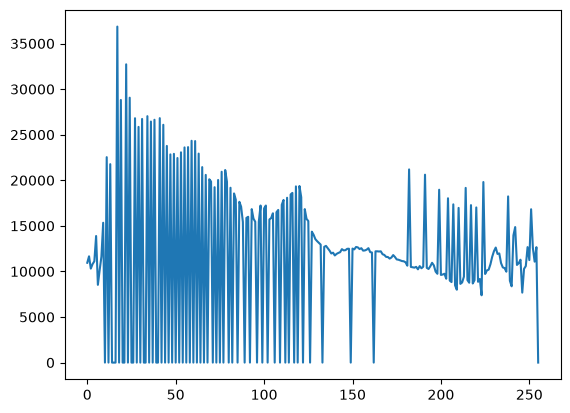

In [36]:
hist = cv2.calcHist([eq_gray], [0], None, [256], [0, 256])
plt.plot(hist)

### Статистическая цветокоррекция

$C_t^{new} = E_s + (C_t - E_t) \cdot \frac{D_s}{D_t}$

In [40]:
E_s = eq_gray.mean()
D_s = eq_gray.std()

E_t = image.mean()
D_t = image.std()

matched = E_s + (image - E_t) * D_s / D_t
matched = np.clip(matched, 0, 255).astype(np.uint8)

In [43]:
print(f"eq_gray: mean={E_s:.2f}, std={D_s:.2f}")
print(f"image  : mean={E_t:.2f}, std={D_t:.2f}")
print(f"matched: mean={matched.mean():.2f}, std={matched.std():.2f}")

eq_gray: mean=127.68, std=73.40
image  : mean=102.02, std=61.64
matched: mean=126.31, std=71.72


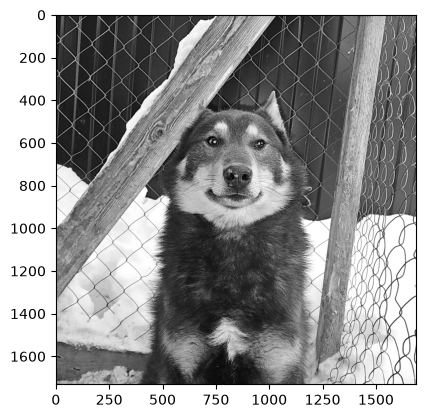

In [45]:
plt.imshow(matched, cmap='gray')

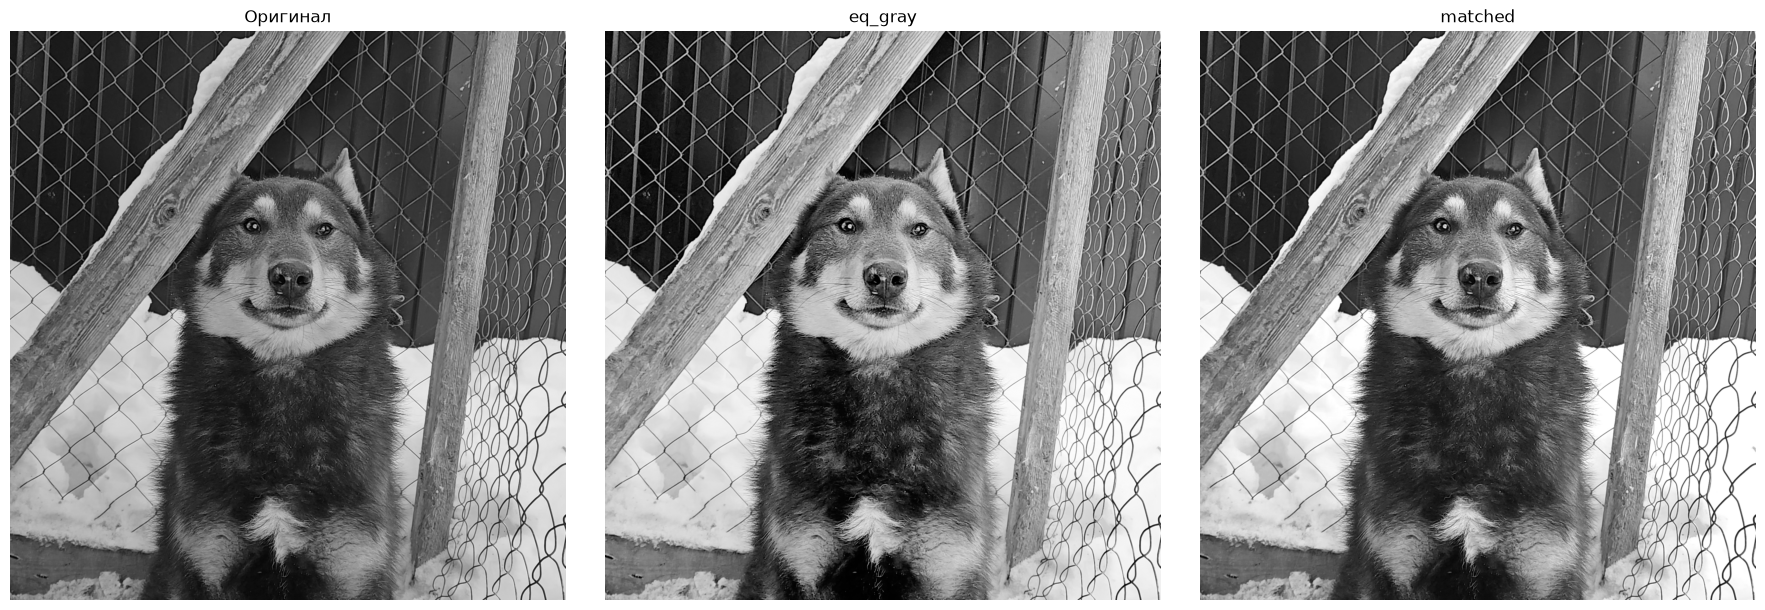

In [46]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray'); plt.title('Оригинал'); plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(eq_gray, cmap='gray'); plt.title('eq_gray'); plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(matched, cmap='gray'); plt.title('matched'); plt.axis('off')

plt.tight_layout()
plt.show()

## 6. Пороговая фильтрация

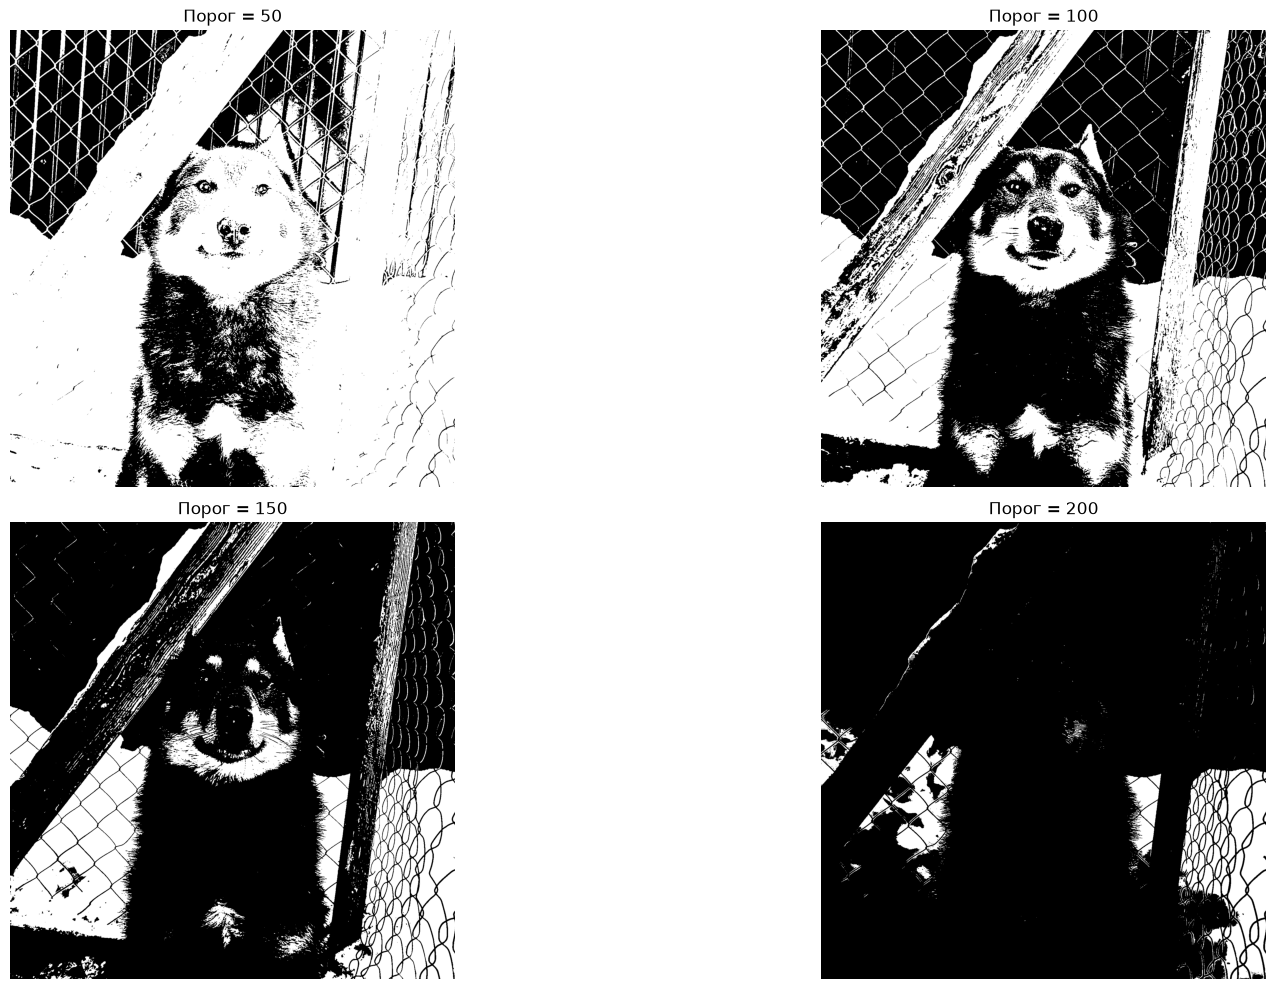

In [48]:
plt.figure(figsize=(20, 10))
for i, t in enumerate([50, 100, 150, 200]):
    _, thresh_image = cv2.threshold(image, t, 255, cv2.THRESH_BINARY)
    plt.subplot(2, 2, i + 1)
    plt.imshow(thresh_image, cmap='gray')
    plt.title(f'Порог = {t}')
    plt.axis('off')
plt.tight_layout()
plt.show()